Check sin(theta_p) ≈ n d_s / P: 0.8613148675101684 0.8613148675101684

--- Helix parameters ---
Filament radius R_f        = 25.000
Helix radius R_h           = 26.000
R_h / R_f                  = 1.0400
Overlap Ω_C                = 0.170
Center-center spacing d_s  = 41.500
Pitch P                    = 96.364
Pitch angle θ_p (deg)      = 59.46
Number of filaments n      = 2
------------------------

--- Helix geometry ---
Number of helix turns      = 3
Pitch P                    = 96.364
Total helix length (z)     = 289.093
-----------------------



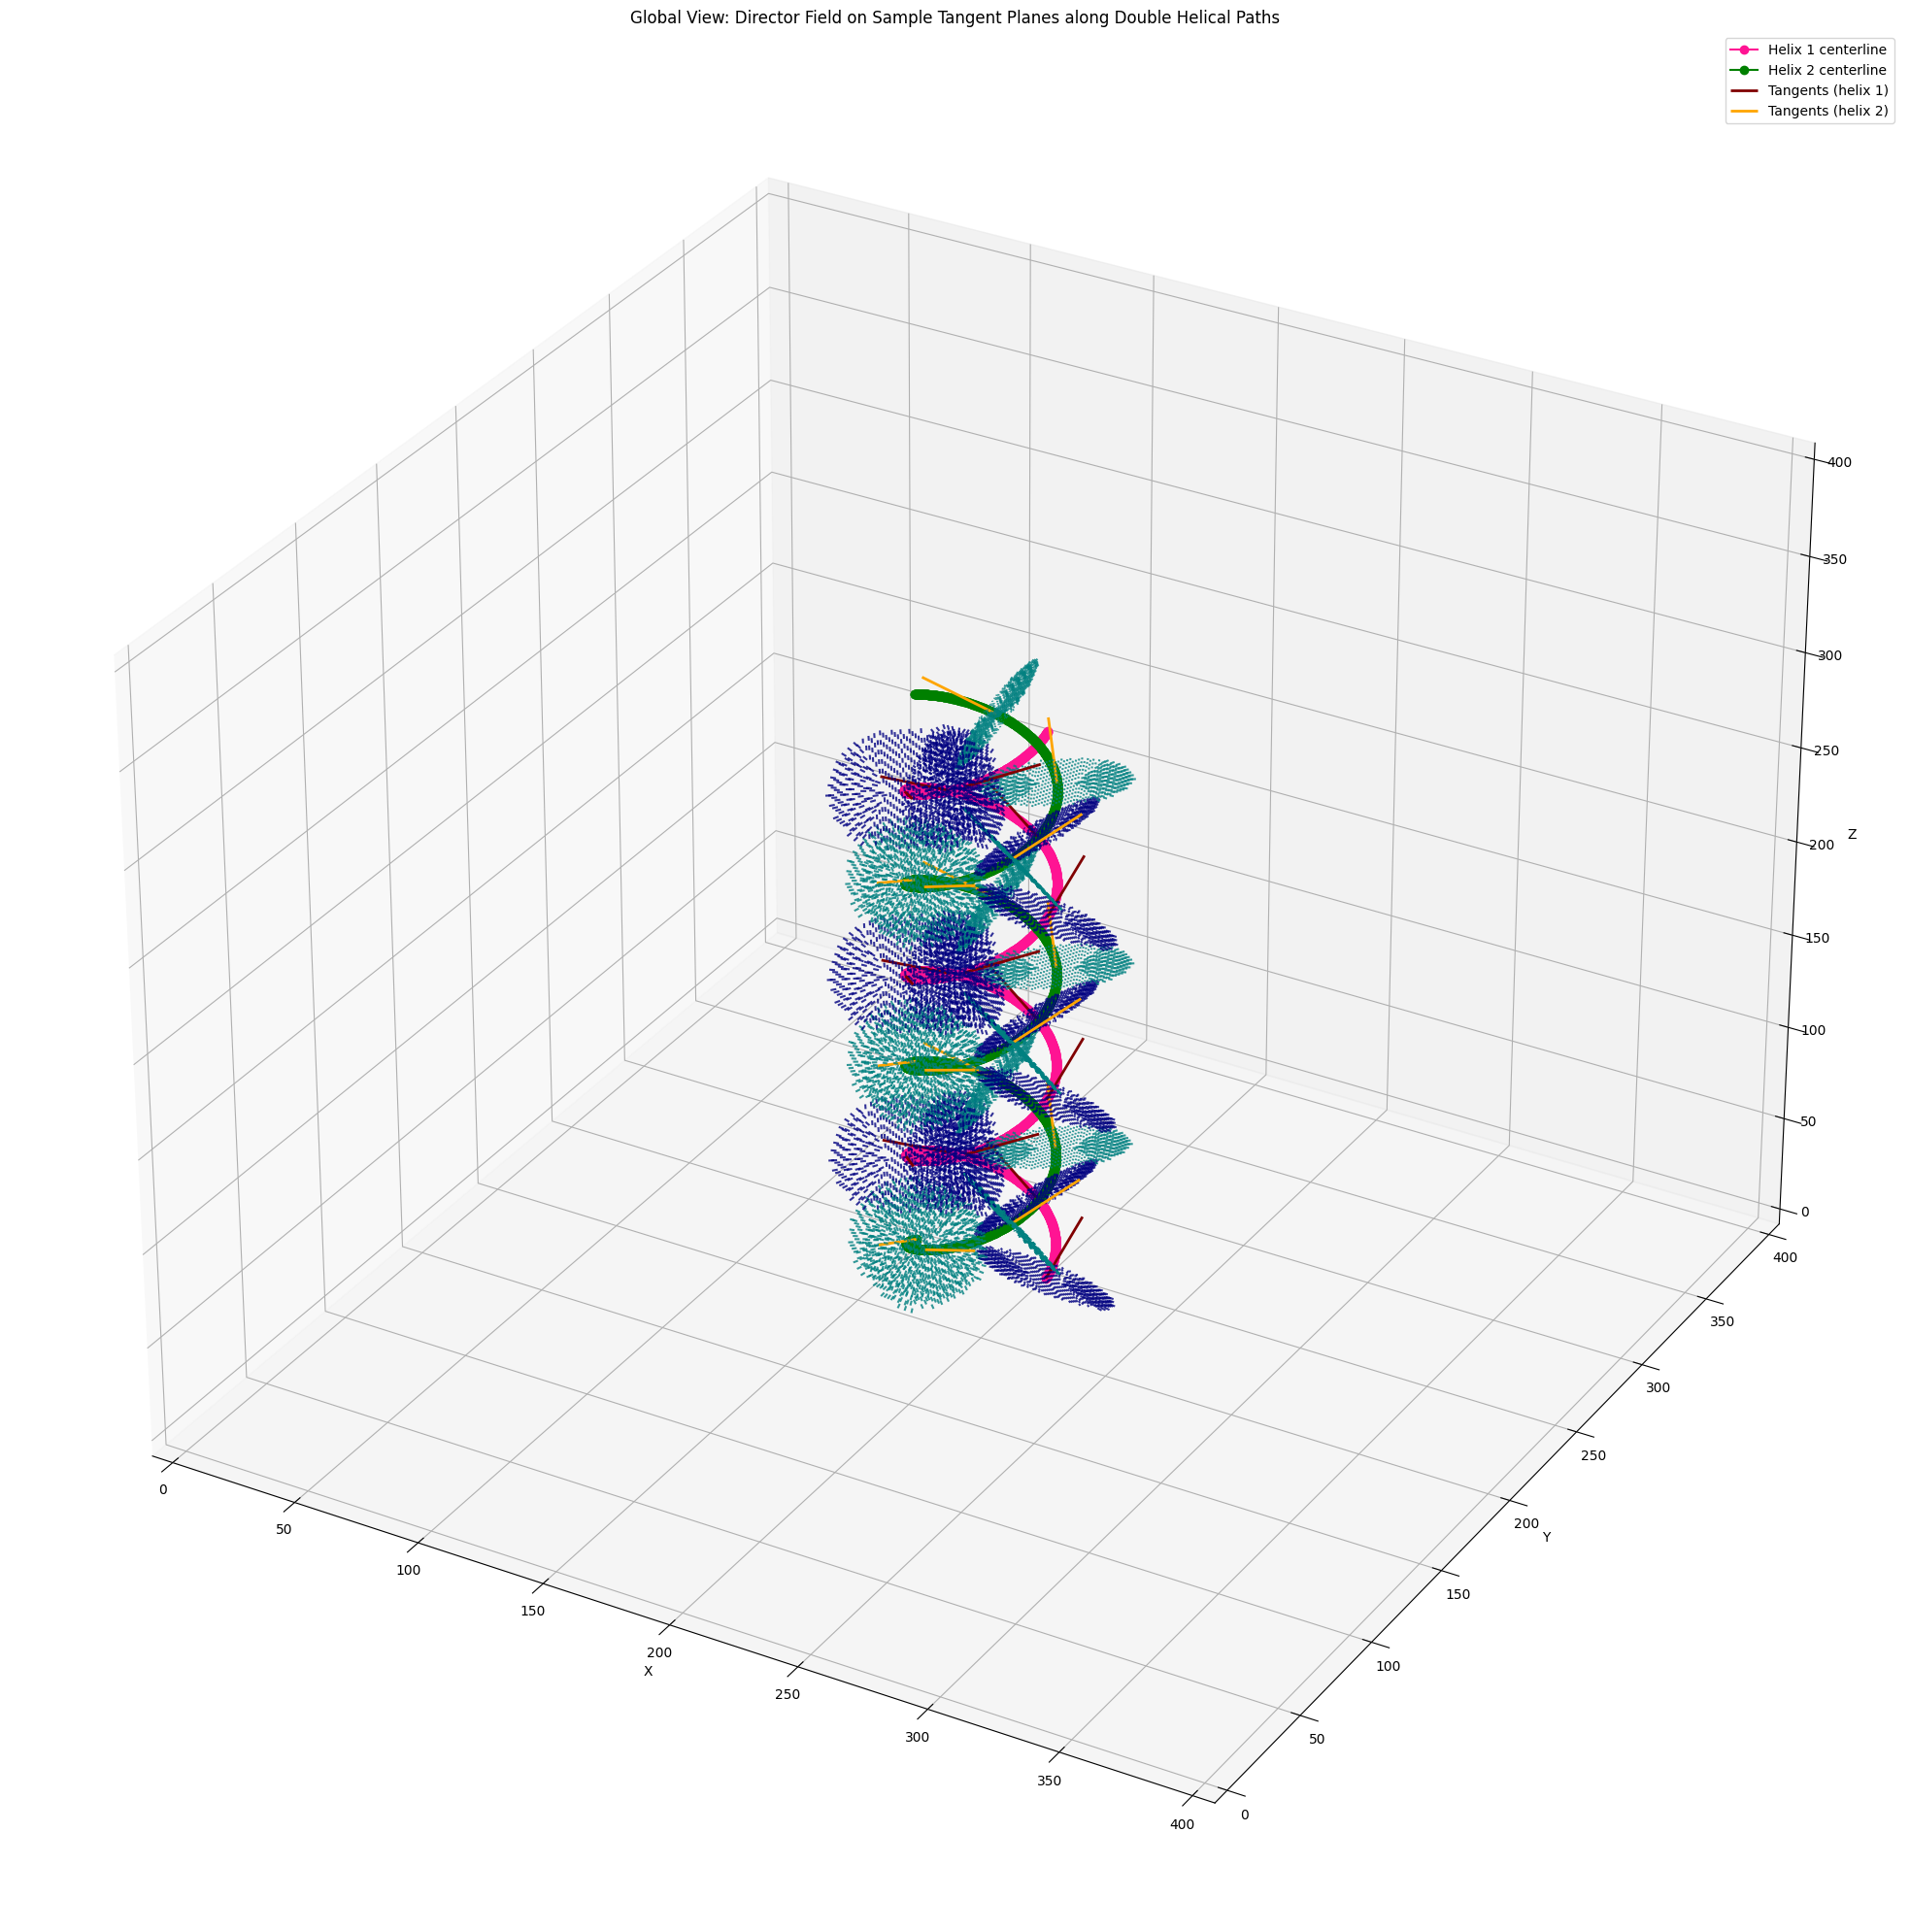

Director field complete! Shape: (400, 400, 400, 3)


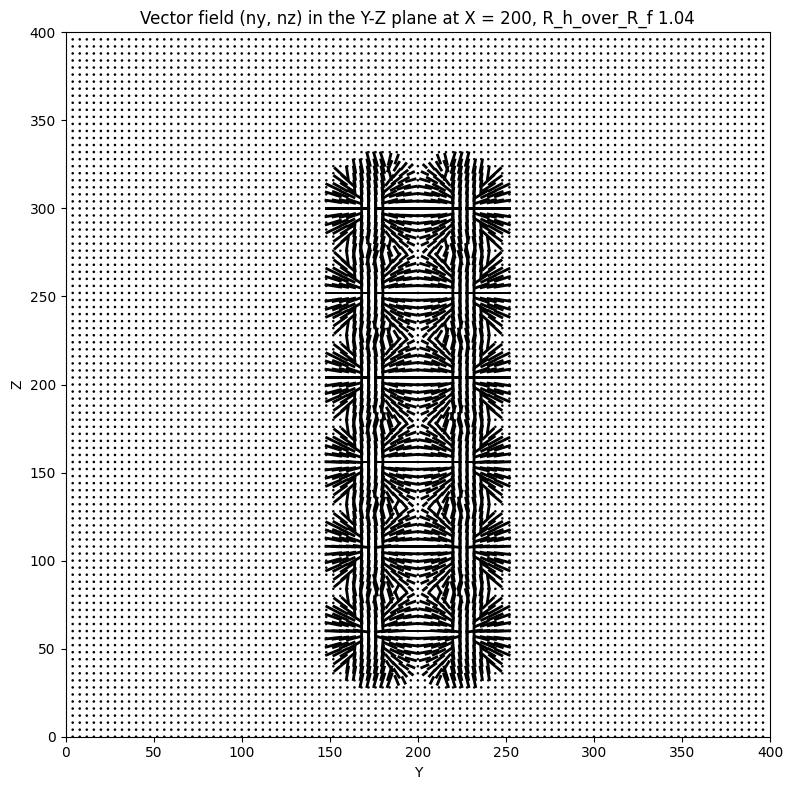

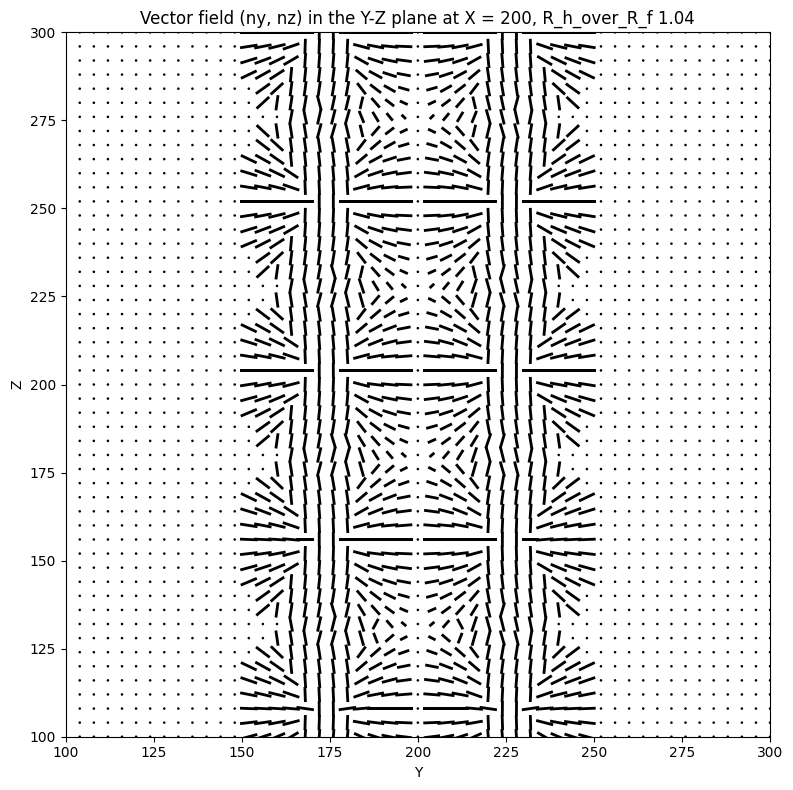

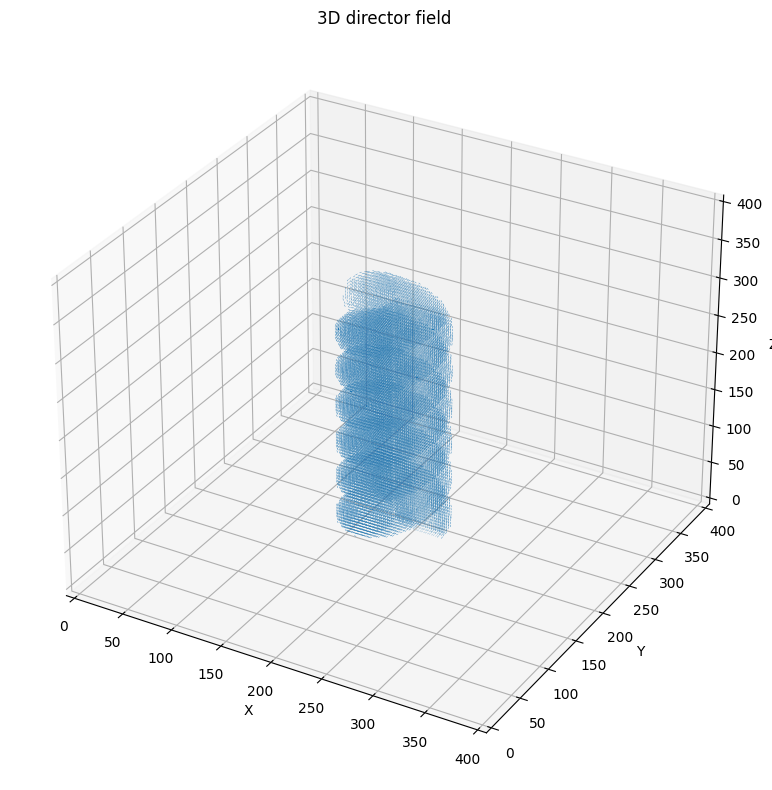

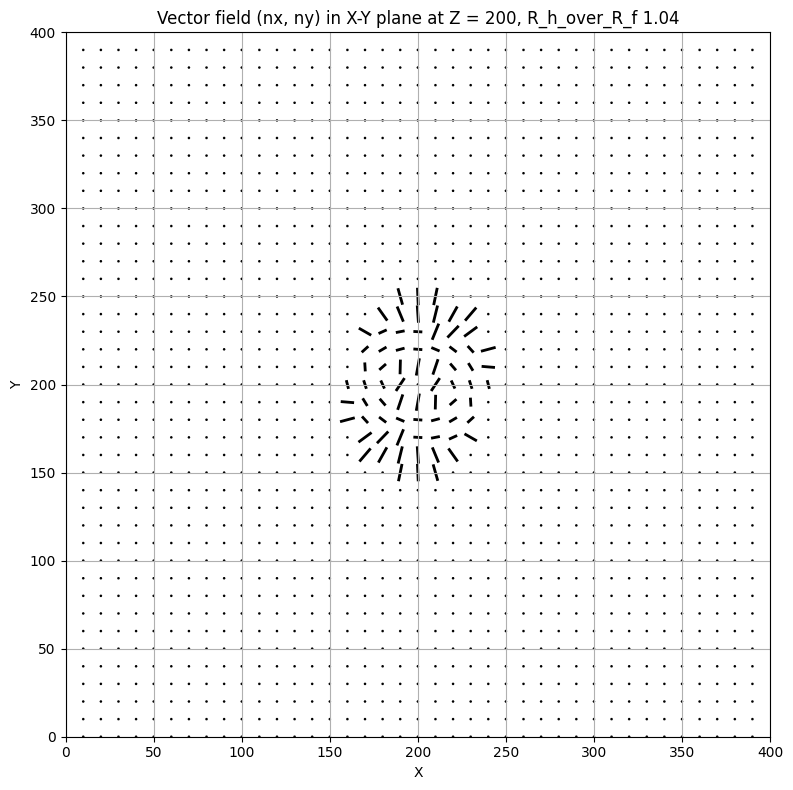

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
from scipy.spatial import cKDTree
import multiprocessing as mp
from scipy.ndimage import affine_transform


# ----------------------------
# Director-field primitives
# ----------------------------
def create_director_circ_w_parabola_both_ways(
    X, Y, Z,
    nx, ny, nz,
    Cx, Cy, Cz,
    R_f, f
):
    """
    Director field in a single circular region of radius R_f centered at (Cx, Cy),
    with two parabolas opening in ±y that define a central 'vertical' region.

    Inside parabola region: n = (0, 1, 0)
    Outside (but inside circle): n = radial from center in x-y.

    Returns nx, ny, nz (float64 arrays).
    """
    nx = nx.astype(np.float64)
    ny = ny.astype(np.float64)
    nz = nz.astype(np.float64)

    distances_squared = (X - Cx) ** 2 + (Y - Cy) ** 2
    distances = np.sqrt(distances_squared)

    mask_circ = distances <= R_f
    distances = np.where(distances < 1e-6, 1e-6, distances)

    parabola_mask1 = (4 * f * (Y - Cy + f)) >= (X - Cx) ** 2
    parabola_mask2 = (4 * f * (Cy - Y + f)) >= (X - Cx) ** 2

    inside_parabola = mask_circ & (parabola_mask1 | parabola_mask2)
    outside_parabola = mask_circ & ~(parabola_mask1 | parabola_mask2)

    # Inside parabola: vertical director (+y)
    nx[inside_parabola] = 0.0
    ny[inside_parabola] = 1.0
    nz[inside_parabola] = 0.0

    # Outside parabola: radial in x-y
    x_val = (X[outside_parabola] - Cx) / distances[outside_parabola]
    y_val = (Y[outside_parabola] - Cy) / distances[outside_parabola]
    nx[outside_parabola] = x_val
    ny[outside_parabola] = y_val
    nz[outside_parabola] = 0.0

    return nx, ny, nz


# ----------------------------
# Helix + frames
# ----------------------------
def create_helical_path(center, R_h, P, num_points, num_turns, phase=0.0):
    """
    Helical centerline with an x-y phase offset that does NOT change z.
    Returns X, Y, Z, theta (base), theta_xy (phase-shifted for x-y).
    """
    Cx, Cy, Cz = center

    theta = np.linspace(0.0, 2.0 * np.pi * num_turns, num_points)
    theta_xy = theta + phase

    X = Cx + R_h * np.cos(theta_xy)
    Y = Cy + R_h * np.sin(theta_xy)
    Z = Cz + (P / (2.0 * np.pi)) * theta

    return X, Y, Z, theta, theta_xy


def create_tangent_vectors(R_h, P, theta, theta_xy):
    """
    Unit tangent vectors for phase-shifted helix.
    x-y uses theta_xy; z uses theta.
    """
    dz_const = P / (2.0 * np.pi)

    dx_dtheta = -R_h * np.sin(theta_xy)
    dy_dtheta =  R_h * np.cos(theta_xy)
    dz_dtheta = dz_const * np.ones_like(theta)

    norm = np.sqrt(dx_dtheta**2 + dy_dtheta**2 + dz_dtheta**2)
    norm[norm == 0] = 1.0

    return dx_dtheta / norm, dy_dtheta / norm, dz_dtheta / norm


def compute_local_frame(T):
    """
    Given a tangent vector T, return two orthonormal vectors (u, v)
    spanning the plane perpendicular to T.
    """
    T = T / np.linalg.norm(T)
    if abs(T[2]) < 0.99:
        arbitrary = np.array([0.0, 0.0, 1.0])
    else:
        arbitrary = np.array([0.0, 1.0, 0.0])

    u = np.cross(arbitrary, T)
    u /= np.linalg.norm(u)
    v = np.cross(T, u)
    return u, v


# ----------------------------
# Scattered -> grid interpolation (multiprocessing-friendly)
# ----------------------------
def interpolate_single_slice(args):
    """
    Worker: interpolate one z-slice using nearest-neighbor with a distance threshold.
    Returns a (Lx, Ly, 3) float32 array.
    """
    k, Lx, Ly, tree, final_vectors, max_distance = args

    Xg, Yg = np.meshgrid(np.arange(Lx), np.arange(Ly), indexing="ij")
    Zg = np.full_like(Xg, k)
    grid_coords = np.stack((Xg, Yg, Zg), axis=-1).reshape(-1, 3)

    distances, indices = tree.query(grid_coords, k=1)
    vecs = final_vectors[indices].copy()
    vecs[distances > max_distance] = 0.0

    return vecs.reshape(Lx, Ly, 3).astype(np.float32)


# ----------------------------
# Rotation + export
# ----------------------------
def rotate_volume_and_vectors(nx, ny, nz, R):
    """
    Rotate a 3D vector field stored as separate component volumes (nx, ny, nz)
    by rotation matrix R.

    Steps:
      1) affine_transform volumes using inverse rotation (resampling)
      2) rotate vectors with forward R
    """
    R_inv = np.linalg.inv(R)
    center = np.array(nx.shape) / 2.0

    def apply_rotation(data):
        return affine_transform(
            data,
            matrix=R_inv,
            offset=center - R_inv @ center,
            order=1,
            mode="nearest",
        )

    nx_r = apply_rotation(nx)
    ny_r = apply_rotation(ny)
    nz_r = apply_rotation(nz)

    directors = np.stack((nx_r, ny_r, nz_r), axis=-1)
    rotated = directors @ R.T

    return rotated[..., 0], rotated[..., 1], rotated[..., 2]


def export_directors(X, Y, Z,
                     nx, ny, nz,
                     dx, dy, dz,
                     outdir, filename):
    """
    Write director field (with coordinates) to a text file with two header lines.
    """
    os.makedirs(outdir, exist_ok=True)

    Lx, Ly, Lz = X.shape
    header1 = f"{Lx} {Ly} {Lz} {dx:.4f} {dy:.4f} {dz:.4f}"
    header2 = f"0 {Lx-1} 0 {Ly-1} 0 {Lz-1}"

    data = np.stack([
        X.ravel(), Y.ravel(), Z.ravel(),
        nx.ravel(), ny.ravel(), nz.ravel()
    ], axis=1)

    path = os.path.join(outdir, filename)
    with open(path, "w") as f:
        f.write(header1 + "\n")
        f.write(header2 + "\n")
        np.savetxt(f, data, fmt="%.6f")

    print(f"Saved: {path}")


# ----------------------------
# Plot helpers (optional but keeps main() readable)
# ----------------------------
def plot_global_tangent_plane_samples(
    all_global_points, all_global_vectors,
    X_path_1, Y_path_1, Z_path_1,
    X_path_2, Y_path_2, Z_path_2,
    tangent_x_1, tangent_y_1, tangent_z_1,
    tangent_x_2, tangent_y_2, tangent_z_2,
    Lx, Ly, Lz,
    num_points,
    n_p=200,
    sample_rate=4
):
    fig = plt.figure(figsize=(24, 20))
    ax = fig.add_subplot(111, projection="3d")

    for i, (pts, vecs) in enumerate(zip(all_global_points, all_global_vectors)):
        if i % n_p == 0:
            color = "navy" if i < num_points else "teal"
            ax.quiver(
                pts[::sample_rate, 0],
                pts[::sample_rate, 1],
                pts[::sample_rate, 2],
                vecs[::sample_rate, 0],
                vecs[::sample_rate, 1],
                vecs[::sample_rate, 2],
                length=2.0,
                color=color,
                alpha=0.8,
                arrow_length_ratio=0
            )

    ax.plot(X_path_1, Y_path_1, Z_path_1, "o-", color="deeppink", label="Helix 1 centerline")
    ax.plot(X_path_2, Y_path_2, Z_path_2, "o-", color="green", label="Helix 2 centerline")

    # Tangent vectors sampled
    for j, (x, y, z, tx, ty, tz) in enumerate(zip(X_path_1, Y_path_1, Z_path_1, tangent_x_1, tangent_y_1, tangent_z_1)):
        if j % n_p == 0:
            ax.quiver(x, y, z, tx, ty, tz, length=30, color="maroon", linewidths=2,
                      arrow_length_ratio=0, label="Tangents (helix 1)" if j == 0 else None)

    for j, (x, y, z, tx, ty, tz) in enumerate(zip(X_path_2, Y_path_2, Z_path_2, tangent_x_2, tangent_y_2, tangent_z_2)):
        if j % n_p == 0:
            ax.quiver(x, y, z, tx, ty, tz, length=30, color="orange", linewidths=2,
                      arrow_length_ratio=0, label="Tangents (helix 2)" if j == 0 else None)

    ax.set_title("Global View: Director Field on Sample Tangent Planes along Double Helical Paths")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_xlim([0, Lx]); ax.set_ylim([0, Ly]); ax.set_zlim([0, Lz])
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_slice_yz(ny, nz, X, Y, Z, x_display, Rh_over_Rf, lims=None, k=4,
                  scale=40, width=0.004, title_prefix="Vector field (ny, nz) in the Y-Z plane"):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.quiver(
        Y[x_display, ::k, ::k], Z[x_display, ::k, ::k],
        ny[x_display, ::k, ::k], nz[x_display, ::k, ::k],
        pivot="middle", scale=scale, width=width,
        headaxislength=0, headlength=0, headwidth=1, linewidths=width
    )
    ax.set_xlabel("Y"); ax.set_ylabel("Z")
    if lims is None:
        ax.set_xlim([0, Y.shape[1]])
        ax.set_ylim([0, Z.shape[2]])
    else:
        (y0, y1), (z0, z1) = lims
        ax.set_xlim([y0, y1])
        ax.set_ylim([z0, z1])
    ax.set_title(f"{title_prefix} at X = {x_display}, R_h_over_R_f {Rh_over_Rf}")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


def plot_slice_xy(nx, ny, X, Y, z_display, Rh_over_Rf, k=10,
                  scale=40, width=0.004):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.quiver(
        X[::k, ::k, z_display],
        Y[::k, ::k, z_display],
        nx[::k, ::k, z_display],
        ny[::k, ::k, z_display],
        pivot="middle", scale=scale, width=width,
        headaxislength=0, headlength=0, headwidth=1, linewidths=width
    )
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_xlim([0, X.shape[0]])
    ax.set_ylim([0, Y.shape[1]])
    ax.set_title(f"Vector field (nx, ny) in X-Y plane at Z = {z_display}, R_h_over_R_f {Rh_over_Rf}")
    ax.set_aspect("equal")
    plt.grid()
    plt.tight_layout()
    plt.show()


def plot_3d_quiver(nx, ny, nz, X, Y, Z, k=4, scale=4, title="3D director field"):
    X_sub = X[::k, ::k, ::k]
    Y_sub = Y[::k, ::k, ::k]
    Z_sub = Z[::k, ::k, ::k]
    nx_sub = nx[::k, ::k, ::k]
    ny_sub = ny[::k, ::k, ::k]
    nz_sub = nz[::k, ::k, ::k]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.quiver(
        X_sub, Y_sub, Z_sub,
        nx_sub, ny_sub, nz_sub,
        length=1.0 / scale,
        normalize=True
    )
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(title)
    ax.set_xlim(0, X.shape[0]); ax.set_ylim(0, Y.shape[1]); ax.set_zlim(0, Z.shape[2])
    plt.tight_layout()
    plt.show()


# ----------------------------
# Main
# ----------------------------
def main():
    # ----------------------------
    # Box size
    # ----------------------------
    Lx = Ly = Lz = 400

    # ----------------------------
    # Filament & helix parameters
    # ----------------------------
    R_f = 25.0              # filament radius
    Omega_C = 0.17          # overlap extent
    Rh_over_Rf = 1.04       # ratio R_h / R_f
    R_h = Rh_over_Rf * R_f  # helix radius
    f = (Omega_C * R_f) / 2.0
    n_filaments = 2

    # ----------------------------
    # Geometric relations
    # ----------------------------
    d_s = 2.0 * R_f * (1.0 - Omega_C)

    sqrt_arg = 1.0 - (2.0 * R_f * (1.0 - Omega_C) / (np.pi * R_h)) ** 2
    if sqrt_arg <= 0:
        raise ValueError("Chosen (R_f, R_h, Omega_C) give no valid helix: sqrt argument ≤ 0.")
    P = (4.0 * R_f * (1.0 - Omega_C)) / np.sqrt(sqrt_arg)

    theta_p = np.arctan2(2.0 * np.pi * R_h, P)

    lhs = np.sin(theta_p)
    rhs = n_filaments * d_s / P
    print("Check sin(theta_p) ≈ n d_s / P:", lhs, rhs)
    print("\n--- Helix parameters ---")
    print(f"Filament radius R_f        = {R_f:.3f}")
    print(f"Helix radius R_h           = {R_h:.3f}")
    print(f"R_h / R_f                  = {R_h / R_f:.4f}")
    print(f"Overlap Ω_C                = {Omega_C:.3f}")
    print(f"Center-center spacing d_s  = {d_s:.3f}")
    print(f"Pitch P                    = {P:.3f}")
    print(f"Pitch angle θ_p (deg)      = {np.degrees(theta_p):.2f}")
    print(f"Number of filaments n      = {n_filaments}")
    print("------------------------")

    # ----------------------------
    # Helix length & discretization
    # ----------------------------
    helix_turns = 3
    helix_length = P * helix_turns
    num_points = 3000

    print("\n--- Helix geometry ---")
    print(f"Number of helix turns      = {helix_turns}")
    print(f"Pitch P                    = {P:.3f}")
    print(f"Total helix length (z)     = {helix_length:.3f}")
    print("-----------------------\n")

    # ----------------------------
    # Global centers for the double helix (same z start; phase handles offset)
    # ----------------------------
    global_center_1 = np.array([Lx / 2.0, Ly / 2.0, 1.4 * R_f])
    global_center_2 = np.array([Lx / 2.0, Ly / 2.0, 1.4 * R_f])

    # Helix 1: phase 0
    X_path_1, Y_path_1, Z_path_1, theta_1, theta_xy_1 = create_helical_path(
        global_center_1, R_h, P, num_points, helix_turns, phase=0.0
    )
    tangent_x_1, tangent_y_1, tangent_z_1 = create_tangent_vectors(R_h, P, theta_1, theta_xy_1)

    # Helix 2: phase pi
    X_path_2, Y_path_2, Z_path_2, theta_2, theta_xy_2 = create_helical_path(
        global_center_2, R_h, P, num_points, helix_turns, phase=np.pi
    )
    tangent_x_2, tangent_y_2, tangent_z_2 = create_tangent_vectors(R_h, P, theta_2, theta_xy_2)

    # ----------------------------
    # For each point on helical path, generate a tangent-plane director patch
    # ----------------------------
    plane_half_range = 2 * R_f
    plane_res = int(2 * plane_half_range) + 1

    local_coords = np.linspace(-plane_half_range, plane_half_range, plane_res)
    X_local, Y_local = np.meshgrid(local_coords, local_coords, indexing="ij")
    Z_local = np.zeros_like(X_local)

    all_global_points = []
    all_global_vectors = []

    def accumulate_filament(X_path, Y_path, Z_path, tx, ty, tz):
        for i in range(len(X_path)):
            origin = np.array([X_path[i], Y_path[i], Z_path[i]])
            tangent = np.array([tx[i], ty[i], tz[i]])
            u, v = compute_local_frame(tangent)

            nx_local = np.full_like(X_local, np.nan, dtype=float)
            ny_local = np.full_like(Y_local, np.nan, dtype=float)
            nz_local = np.full_like(Z_local, np.nan, dtype=float)

            nx_local, ny_local, nz_local = create_director_circ_w_parabola_both_ways(
                X_local, Y_local, Z_local,
                nx_local, ny_local, nz_local,
                Cx=0.0, Cy=0.0, Cz=0.0,
                R_f=R_f, f=f
            )

            mask = (~np.isnan(nx_local)) & (~np.isnan(ny_local)) & (~np.isnan(nz_local))
            valid_X = X_local[mask]
            valid_Y = Y_local[mask]
            valid_nx = nx_local[mask]
            valid_ny = ny_local[mask]

            pts = origin + valid_X[:, None] * u + valid_Y[:, None] * v
            vecs = valid_nx[:, None] * u + valid_ny[:, None] * v

            all_global_points.append(pts)
            all_global_vectors.append(vecs)

    accumulate_filament(X_path_1, Y_path_1, Z_path_1, tangent_x_1, tangent_y_1, tangent_z_1)
    accumulate_filament(X_path_2, Y_path_2, Z_path_2, tangent_x_2, tangent_y_2, tangent_z_2)

    # ----------------------------
    # Visualization of scattered tangent-plane samples (optional)
    # ----------------------------
    plot_global_tangent_plane_samples(
        all_global_points, all_global_vectors,
        X_path_1, Y_path_1, Z_path_1,
        X_path_2, Y_path_2, Z_path_2,
        tangent_x_1, tangent_y_1, tangent_z_1,
        tangent_x_2, tangent_y_2, tangent_z_2,
        Lx, Ly, Lz,
        num_points,
        n_p=200,
        sample_rate=4
    )

    # ----------------------------
    # Interpolate to regular grid
    # ----------------------------
    all_points_flat = [pts.reshape(-1, 3) for pts in all_global_points]
    all_vectors_flat = [vecs.reshape(-1, 3) for vecs in all_global_vectors]
    final_points = np.concatenate(all_points_flat, axis=0)
    final_vectors = np.concatenate(all_vectors_flat, axis=0)

    final_points = np.nan_to_num(final_points, nan=0.0)
    final_vectors = np.nan_to_num(final_vectors, nan=0.0)

    tree = cKDTree(final_points)
    max_distance = 1.0

    pool_args = [(k, Lx, Ly, tree, final_vectors, max_distance) for k in range(Lz)]
    # NOTE: adjust processes for your machine
    with mp.get_context("fork").Pool(processes=32) as pool:
        director_slices = pool.map(interpolate_single_slice, pool_args)

    director = np.stack(director_slices, axis=2)  # (Lx, Ly, Lz, 3)
    print("Director field complete! Shape:", director.shape)

    nx = director[..., 0]
    ny = director[..., 1]
    nz = director[..., 2]

    X, Y, Z = np.meshgrid(np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing="ij")

    # ----------------------------
    # Slice / 3D visualizations (optional)
    # ----------------------------
    x_display = int(Lx / 2)

    plot_slice_yz(ny, nz, X, Y, Z, x_display, Rh_over_Rf, lims=None, k=4)
    plot_slice_yz(ny, nz, X, Y, Z, x_display, Rh_over_Rf, lims=((100, 300), (100, 300)), k=4)

    plot_3d_quiver(nx, ny, nz, X, Y, Z, k=4, scale=4, title="3D director field")

    z_display = 200
    plot_slice_xy(nx, ny, X, Y, z_display, Rh_over_Rf, k=10)

    # ----------------------------
    # Rotate + export
    # ----------------------------
    r_e_values = np.array([0.7]) * 1e-6  # meters (your convention)
    theta_values = [85, 80, 75, 70, 65, 60, 55, 50, 45]

    outdir = "lc-pom/Interpolated_Director_Field"

    L_str = Lx
    r_val = R_f
    np_val = num_points
    r_str = f"{r_val:.1f}".replace(".", "p")
    o_str = f"{Omega_C:.3f}".replace(".", "p")

    for r_e in r_e_values:
        res = r_e / R_f
        d_pom = round(res * 1e6, 6)
        dx = dy = dz = d_pom

        re_um = r_e * 1e6
        re_str = f"{re_um:.1f}".replace(".", "p")

        for theta in theta_values:
            theta_rad = np.radians(theta)
            Rx = np.array([
                [1, 0, 0],
                [0, np.cos(theta_rad), -np.sin(theta_rad)],
                [0, np.sin(theta_rad),  np.cos(theta_rad)],
            ])

            nx_rot, ny_rot, nz_rot = rotate_volume_and_vectors(nx, ny, nz, Rx)

            filename = (
                f"rotated_{theta}_double_helix_L_{L_str}_o_{o_str}_r_{r_str}_"
                f"np_{np_val}_re_{re_str}um.txt"
            )

            #export_directors(X, Y, Z, nx_rot, ny_rot, nz_rot, dx, dy, dz, outdir, filename)


if __name__ == "__main__":
    main()